<a href="https://colab.research.google.com/github/RitajM1/arti560-computer-vision-labs/blob/main/lab10_visual_representations_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [ ]:
# Provide your solution here
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoImageProcessor, AutoModel
import numpy as np

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model loaded on cuda


In [ ]:
@torch.no_grad()
def get_cls_embedding(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    outputs = model(**inputs)

    # CLS token is index 0
    cls_token = outputs.last_hidden_state[:, 0]

    # Normalize so KMeans works on direction/semantic similarity
    cls_token = F.normalize(cls_token, p=2, dim=1)

    return cls_token.squeeze().cpu().numpy()

In [ ]:
data_dir = "."

image_paths = []
labels = []

cat_keywords = [
    "abyssinian", "bengal", "birman", "bombay",
    "maine", "persian", "ragdoll", "siamese", "sphynx"
]

for fname in os.listdir(data_dir):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(data_dir, fname)
        lower = fname.lower()

        is_cat = any(cat in lower for cat in cat_keywords)

        if is_cat:
            labels.append(0)   # cat
        else:
            labels.append(1)   # dog

        image_paths.append(path)

image_paths = image_paths[:20]
labels = labels[:20]

print("Images used:", len(image_paths))
print("Ground truth labels:", labels)
print("First files:", image_paths[:5])

Images used: 20
Ground truth labels: [0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0]
First files: ['./Abyssinian_134.jpg', './Abyssinian_144.jpg', './Abyssinian_139.jpg', './Abyssinian_173.jpg', './american_bulldog_122.jpg']


In [ ]:
features = []

for path in image_paths:
    emb = get_cls_embedding(path)
    features.append(emb)

features = np.array(features)

print("Feature matrix shape:", features.shape)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features)

print("Predicted clusters:", clusters)
print("True labels:", labels)

Feature matrix shape: (20, 384)
Predicted clusters: [1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1]
True labels: [0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0]


In [ ]:
# KMeans cluster IDs are arbitrary
acc1 = accuracy_score(labels, clusters)
acc2 = accuracy_score(labels, 1 - clusters)

if acc2 > acc1:
    final_preds = 1 - clusters
    final_acc = acc2
else:
    final_preds = clusters
    final_acc = acc1

print("Final predicted labels:", final_preds)
print("Accuracy:", final_acc)
print("Confusion Matrix:")
print(confusion_matrix(labels, final_preds))

Final predicted labels: [0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 0 1 0 0]
Accuracy: 1.0
Confusion Matrix:
[[10  0]
 [ 0 10]]


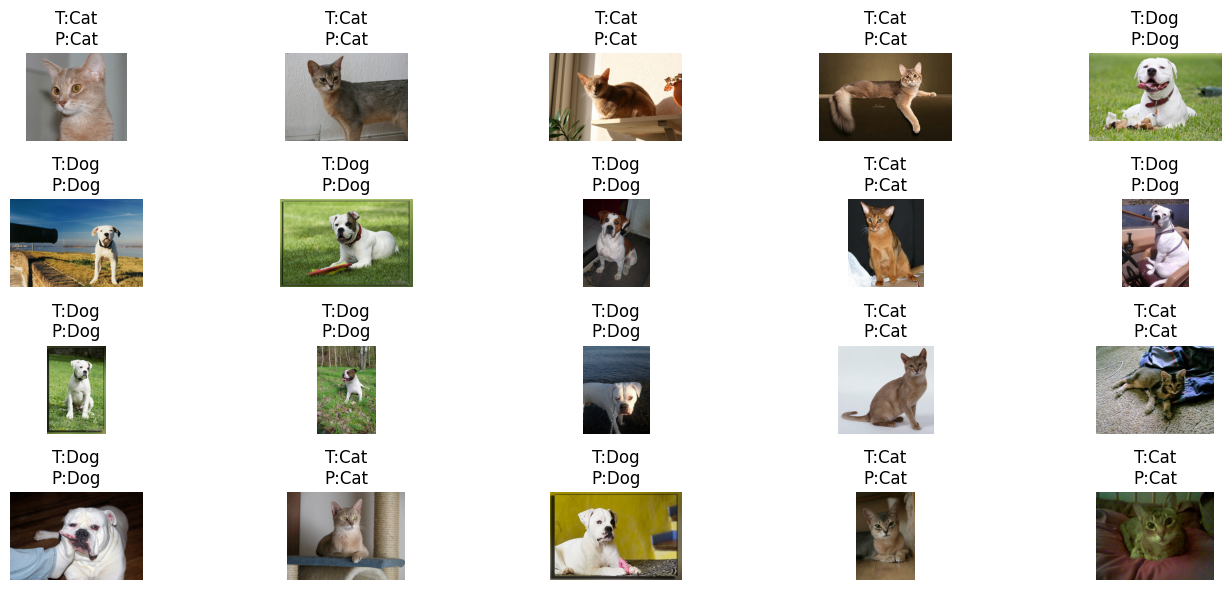

In [ ]:
plt.figure(figsize=(14, 6))

for i, path in enumerate(image_paths):
    img = Image.open(path).convert("RGB")
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    true_name = "Dog" if labels[i] == 1 else "Cat"
    pred_name = "Dog" if final_preds[i] == 1 else "Cat"
    plt.title(f"T:{true_name}\nP:{pred_name}")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:
# Provide your solution here
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
clf_model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
clf_model.eval()

print(f"Classification model loaded on {device}")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Classification model loaded on cuda


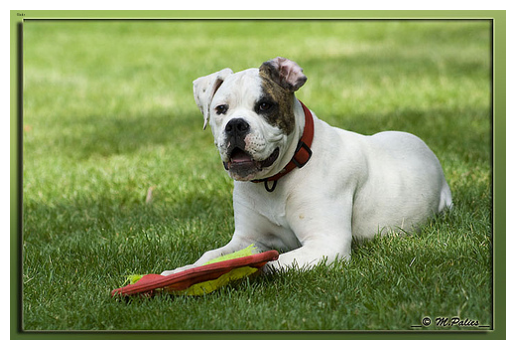

In [ ]:
image_path = "american_bulldog_115.jpg"

img = Image.open(image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
inputs = processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = clf_model(**inputs)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

top5 = torch.topk(probs, k=5)

for score, idx in zip(top5.values[0], top5.indices[0]):
    label = clf_model.config.id2label[idx.item()]
    print(f"{label}: {score.item():.4f}")

boxer: 0.5605
American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier: 0.1720
tennis ball: 0.1559
bull mastiff: 0.0534
Staffordshire bullterrier, Staffordshire bull terrier: 0.0202
